# Comparative Parameter Sensitivity Analysis — Clay-Rich Formation
## Modified Cam-Clay (MCC) — Brine vs H₂ — 100 / 200 / 300 bar

---

### Overview
This notebook performs a **global parameter sensitivity analysis** using **Latin Hypercube Sampling (LHS)** combined with **Standardized Regression Coefficients (SRC)** to quantify how each MCC constitutive parameter influences four key cyclic-response metrics.

### Cases
Six cases are analysed (2 fluids × 3 pressures), each using its own calibrated baseline from `table_guess`.

### Output metrics
| Figure | Metric | Symbol |
|--------|--------|--------|
| Fig A | Cumulative inelastic strain at N=8 | ε_inel(8) |
| Fig B | Ratcheting rate (slope, last 3 cycles) | ε̇_ratch |
| Fig C | Mean loop area (cycles 2–8) | A_loop |
| Fig D | Total axial strain at N=8 | ε_total(8) |

### Notebook structure
| Cell | Content |
|------|---------|
| 01 | Imports & global style |
| 02 | Output directory & `save_fig` helper |
| 03 | Material parameters (`table_guess`) |
| 04 | Sensitivity analysis settings (cases, params, ranges) |
| 05 | Forward model + metric extractor |
| 06 | LHS sampler + SRC solver |
| 07 | Run all simulations (LHS → forward → SRC) |
| 08 | Tornado plot function (`sa_draw`) |
| 09 | Fig A — Sensitivity: ε_inel (N=8) |
| 10 | Fig B — Sensitivity: Ratcheting rate |
| 11 | Fig C — Sensitivity: Mean loop area |
| 12 | Fig D — Sensitivity: ε_total (N=8) |
| 13 | R² summary table |

### All outputs saved to `Outputs_Sensitivity_Analysis_Clay_Rich/`


## Cell 01 — Imports & Global Plotting Style

### Purpose
Load all required Python libraries and set publication-quality Matplotlib defaults shared by every figure cell.

### What you will see
- `"Imports OK"` — no figures produced here.

### Libraries loaded
| Library | Role |
|---------|------|
| `numpy` | Arrays, random sampling, linear algebra, exp functions |
| `matplotlib.pyplot` | Core 2-D plotting engine |
| `matplotlib.patches` | Custom patch handles for legend boxes |
| `matplotlib.ticker` | Axis tick locators and formatters |
| `os` | Folder creation and path handling |


In [19]:
# =============================================================================
# CELL 01 — IMPORTS & GLOBAL PLOTTING STYLE
# =============================================================================

import os                              # folder creation and path joining
import numpy as np                     # numerical arrays, linalg, random, exp
import matplotlib.pyplot as plt        # core 2-D figure / axes plotting engine
import matplotlib.patches as mpatches  # patch objects for custom legend handles
import matplotlib.ticker as mticker    # tick locators and formatters for axes

# ── Global Matplotlib style — publication quality ─────────────────────────────
plt.rcParams.update({
    'font.size'        : 10,           # base font size for all text elements
    'axes.labelsize'   : 11,           # axis label font size
    'axes.labelweight' : 'bold',       # axis labels rendered in bold
    'axes.titlesize'   : 11,           # subplot title font size
    'axes.titleweight' : 'bold',       # subplot titles rendered in bold
    'legend.fontsize'  : 8.5,          # legend entry font size
    'figure.dpi'       : 120,          # screen rendering resolution [dpi]
    'savefig.dpi'      : 300,          # saved-file resolution [dpi]
    'axes.grid'        : True,         # draw background grid on every axis
    'grid.alpha'       : 0.25,         # semi-transparent grid lines
})

print("Imports OK")                    # confirm all libraries loaded without error


Imports OK


## Cell 02 — Output Directory & `save_fig` Helper

### Purpose
Create the output folder **`Outputs_Sensitivity_Analysis_Clay_Rich/`** on disk and define the `save_fig()` function that every figure cell calls to write PDF and PNG files.

### What you will see
- `"Output directory ready: Outputs_Sensitivity_Analysis_Clay_Rich"` — no figures produced here.

### File naming convention
Each figure cell sets `CELL_NAME = "CellXX"` at the very top before calling `save_fig()`.
The resulting filenames follow the pattern:
```
CellXX_FigYY_DescriptiveName.pdf
CellXX_FigYY_DescriptiveName.png
```

### Why two formats?
- **PDF** — vector format, lossless, ideal for journal submission and LaTeX inclusion.
- **PNG** — 600 dpi raster, ideal for reports, presentations, and web display.


In [20]:
# =============================================================================
# CELL 02 — OUTPUT DIRECTORY & FIGURE-SAVE HELPER
# =============================================================================

OUTPUT_DIR = "Outputs_Sensitivity_Analysis_Clay_Rich"            # top-level folder for all saved figures
os.makedirs(OUTPUT_DIR, exist_ok=True) # create folder; silently skip if it exists

CELL_NAME  = "Cell02"                  # default value; each figure cell overrides this

def save_fig(fig_name, fig_obj=None):
    """Save the current (or given) matplotlib figure to OUTPUT_DIR.

    Reads the global CELL_NAME to build the filename prefix.
    Saves both PDF (vector) and high-res PNG (600 dpi) versions.

    Parameters
    ----------
    fig_name : str
        Descriptive suffix, e.g. 'FigA_Sensitivity_eps_inel'.
    fig_obj : matplotlib.figure.Figure, optional
        If given, saves that specific figure. Otherwise saves plt.gcf().
    """
    base      = f"{CELL_NAME}_{fig_name}"              # e.g. Cell09_FigA_...
    pdf_path  = os.path.join(OUTPUT_DIR, base + ".pdf")   # full PDF file path
    png_path  = os.path.join(OUTPUT_DIR, base + ".png")   # full PNG file path

    fig = fig_obj if fig_obj is not None else plt.gcf()    # use provided or current fig

    fig.savefig(pdf_path, bbox_inches='tight', facecolor='white')  # vector PDF
    fig.savefig(png_path, dpi=600, bbox_inches='tight', facecolor='white')  # 600-dpi PNG

    print(f"  Saved -> {pdf_path}")                      # confirm PDF written
    print(f"  Saved -> {png_path}")                      # confirm PNG written

print(f"Output directory ready: {OUTPUT_DIR}")           # echo folder path


Output directory ready: Outputs_Sensitivity_Analysis_Clay_Rich


## Cell 03 — Material Parameters (`table_guess`)

### Purpose
Define the calibrated MCC constitutive parameters for all **six cases** (2 fluids × 3 pressures). These values serve as the **local baseline** around which the sensitivity analysis perturbs each parameter.

### What you will see
- Printed parameter table for all six cases.
- No figures produced here.

### Why case-specific baselines matter
Each case represents a different material state (pressure level, pore-fluid). Using case-specific baselines means the SRC sensitivities reflect the **local model behaviour** at the calibrated operating point — not a single global average.

### Parameter glossary
| Symbol | Key | Unit | Physical meaning |
|--------|-----|------|-----------------|
| φ₀ | `phi0` | — | Initial porosity |
| λ | `lam` | — | NCL slope (plastic compressibility) |
| κ | `kap` | — | URL slope (elastic swelling) |
| M | `M` | — | CSL slope (shear strength) |
| θ | `theta` | — | Cyclic hardening / ratcheting parameter |
| p_c0 | `pc0_MPa` | MPa | Initial preconsolidation pressure |


In [21]:
# =============================================================================
# CELL 03 — MATERIAL PARAMETERS (table_guess)
# =============================================================================

# table_guess — calibrated MCC parameter dictionary for all 6 cases.
# Keys:   (fluid, pressure_label) tuples
# Values: dicts with MCC constitutive parameters

table_guess = {
    # ── Brine cases — generally stiffer, higher pc0, lower porosity ───────────
    ('Brine', '100 bar'): dict(
        phi0    = 0.32,      # initial porosity
        lam     = 0.00285,   # NCL slope (compression index)
        kap     = 0.00055,   # URL slope (swelling/recompression index)
        M       = 0.702,     # critical state slope q/p' at failure
        theta   = 0.0045,    # cyclic hardening / ratcheting coefficient
        pc0_MPa = 13.0,      # initial preconsolidation pressure [MPa]
    ),
    ('Brine', '200 bar'): dict(
        phi0=0.30, lam=0.00220,  kap=0.00045,  M=0.740, theta=0.0045, pc0_MPa=26.0),
    ('Brine', '300 bar'): dict(
        phi0=0.28, lam=0.00190,  kap=0.00040,  M=0.760, theta=0.0045, pc0_MPa=39.0),

    # ── H2 cases — slightly softer, higher porosity, lower pc0 ───────────────
    ('H2', '100 bar'): dict(
        phi0    = 0.33,      # slightly higher porosity than Brine
        lam     = 0.003135,  # larger NCL slope (more compressible)
        kap     = 0.000605,  # larger URL slope (more elastic compliance)
        M       = 0.682,     # slightly lower CSL slope
        theta   = 0.0045,    # same cyclic hardening as Brine
        pc0_MPa = 11.05,     # lower initial yield stress
    ),
    ('H2', '200 bar'): dict(
        phi0=0.31, lam=0.00242,  kap=0.000495, M=0.720, theta=0.0045, pc0_MPa=22.10),
    ('H2', '300 bar'): dict(
        phi0=0.29, lam=0.00209,  kap=0.00044,  M=0.740, theta=0.0045, pc0_MPa=33.15),
}

# ── Print formatted summary ───────────────────────────────────────────────────
print(f"{'Case':<20} {'phi0':>6} {'lam':>9} {'kap':>9} {'M':>6} {'theta':>8} {'pc0 [MPa]':>10}")
print("─" * 72)
for (fluid, press), g in table_guess.items():
    lbl = f"{fluid} {press}"
    print(f"{lbl:<20} {g['phi0']:>6.3f} {g['lam']:>9.5f} {g['kap']:>9.6f} "
          f"{g['M']:>6.3f} {g['theta']:>8.4f} {g['pc0_MPa']:>10.2f}")


Case                   phi0       lam       kap      M    theta  pc0 [MPa]
────────────────────────────────────────────────────────────────────────
Brine 100 bar         0.320   0.00285  0.000550  0.702   0.0045      13.00
Brine 200 bar         0.300   0.00220  0.000450  0.740   0.0045      26.00
Brine 300 bar         0.280   0.00190  0.000400  0.760   0.0045      39.00
H2 100 bar            0.330   0.00314  0.000605  0.682   0.0045      11.05
H2 200 bar            0.310   0.00242  0.000495  0.720   0.0045      22.10
H2 300 bar            0.290   0.00209  0.000440  0.740   0.0045      33.15


## Cell 04 — Sensitivity Analysis Settings

### Purpose
Define all configuration needed by the sensitivity analysis:
- Six study cases with their plotting colors and hatch patterns
- The 13 parameters to vary and their LaTeX display labels
- Relative variation ranges for each parameter
- Loading driver conditions
- Output metric display information (titles, axis labels, filenames)

### What you will see
- Printed confirmation of settings — no figures produced here.

### Why logarithmic LHS sampling?
Parameters like η₁, η₂, and θ span multiple orders of magnitude. Sampling in **log-space** ensures uniform coverage of small and large values, avoiding over-representation of the upper end of the range.

### Relative variation ranges
| Parameter | Range | Reason |
|-----------|-------|--------|
| φ₀ | ±15% | Porosity is well-constrained from core data |
| M | ±12% | Shear strength well-constrained from triaxial tests |
| ν | ±10% | Poisson's ratio very well-constrained |
| η₁, η₂, θ | 50%–200% | Wide uncertainty in time-dependent parameters |
| All others | 70%–130% | Standard ±30% engineering uncertainty |


In [22]:
# =============================================================================
# CELL 04 — SENSITIVITY ANALYSIS SETTINGS
# =============================================================================

# ── Sampling settings ─────────────────────────────────────────────────────────
SA_N_SAMPLES = 120   # number of Latin Hypercube samples per case
SA_SEED      = 42    # fixed random seed for reproducibility across runs
SA_NCYCLES   = 8     # number of loading cycles simulated by the forward model

# ── Six study cases: (fluid, pressure, bar_color, hatch, display_label) ───────
SA_CASES = [
    ('Brine', '100 bar', '#1565C0', '',    'Clay 100 bar - Brine'),  # deep blue, solid
    ('Brine', '200 bar', '#2E7D32', '',    'Clay 200 bar - Brine'),  # dark green, solid
    ('Brine', '300 bar', '#C62828', '',    'Clay 300 bar - Brine'),  # brick red, solid
    ('H2',   '100 bar', '#F57F17', '///', 'Clay 100 bar - H2'),     # amber, hatched
    ('H2',   '200 bar', '#6A1B9A', '///', 'Clay 200 bar - H2'),     # purple, hatched
    ('H2',   '300 bar', '#4E342E', '///', 'Clay 300 bar - H2'),     # brown, hatched
]

# ── Loading driver — peak stress and cycle duration ───────────────────────────
SA_DRIVER = dict(
    q_peak_MPa        = 35.0,    # peak deviatoric stress used in forward model [MPa]
    seconds_per_cycle = 3600.0,  # one cycle duration in seconds
)

# ── 13 parameters varied in the sensitivity analysis ──────────────────────────
SA_PARAMS = [
    'pc0_MPa',    # initial preconsolidation pressure [MPa]
    'sigBP_MPa',  # brittle-plastic threshold stress proxy [MPa]
    'eta2',       # Perzyna creep denominator (viscosity proxy)
    'kap',        # URL slope (elastic swelling index)
    'lam',        # NCL slope (plastic compression index)
    'theta',      # cyclic hardening coefficient
    'M',          # critical state slope q/p'
    'phi0',       # initial porosity
    'nu',         # Poisson's ratio
    'E2_GPa',     # Kelvin-Voigt spring stiffness [GPa]
    'E1_GPa',     # elastic spring stiffness [GPa]
    'eta1_GPa_s', # Kelvin-Voigt dashpot viscosity [GPa·s]
    'Eavg_GPa',   # average effective elastic modulus [GPa]
]

# ── LaTeX display labels for tornado y-axis ───────────────────────────────────
SA_LABELS = {
    'pc0_MPa':    r'$p_{c0}$ [MPa]',          # Initial preconsolidation pressure
    'sigBP_MPa':  r'$\sigma_{BP}$ [MPa]',     # Brittle–plastic threshold stress
    'eta2':       r'$\eta_2$',                # Perzyna viscosity parameter
    'kap':        r'$\kappa$',                # Elastic swelling index
    'lam':        r'$\lambda$',               # Compression index
    'theta':      r'$\theta$',                # Cyclic hardening coefficient
    'M':          r'$M$',                     # Critical state slope
    'phi0':       r'$\phi_0$',                # Initial porosity
    'nu':         r'$\nu$',                   # Poisson’s ratio
    'E2_GPa':     r'$E_2$ [GPa]',             # Kelvin–Voigt spring stiffness
    'E1_GPa':     r'$E_1$ [GPa]',             # Elastic spring stiffness
    'eta1_GPa_s': r'$\eta_1$ [GPa$\cdot$s]',  # Kelvin–Voigt dashpot viscosity
    'Eavg_GPa':   r'$\bar{E}_{avg}$ [GPa]',   # Average effective modulus
}

# ── Relative variation ranges — default ±30% for all parameters ──────────────
SA_REL = {p: (0.70, 1.30) for p in SA_PARAMS}

# Narrow ranges for well-constrained parameters
SA_REL['phi0'] = (0.85, 1.15)   # ±15%: porosity well-constrained from core data
SA_REL['M']    = (0.88, 1.12)   # ±12%: shear strength well-constrained
SA_REL['nu']   = (0.90, 1.10)   # ±10%: Poisson's ratio very well-constrained

# Widen ranges for uncertain time-dependent parameters
SA_REL['eta2']       = (0.50, 2.00)  # 50%–200%: large uncertainty in creep viscosity
SA_REL['eta1_GPa_s'] = (0.50, 2.00)  # 50%–200%: large uncertainty in KV dashpot
SA_REL['theta']      = (0.50, 2.00)  # 50%–200%: large uncertainty in cyclic hardening

# ── Output metric display information (title, x-label, filename) ─────────────
SA_METRIC_INFO = {
    'Y1': dict(
        title  = r'Brine vs H$_2$ (100/200/300 bar): $\varepsilon_{a,\,inel}$ ($N=8$)',
        xlabel = 'Standardized sensitivity coefficient (SRC)',
        fname  = 'FigA_Sensitivity_eps_inel',
    ),
    'Y2': dict(
        title  = r'Brine vs H$_2$ (100/200/300 bar): Ratcheting rate',
        xlabel = 'Standardized sensitivity coefficient (SRC)',
        fname  = 'FigB_Sensitivity_ratcheting',
    ),
    'Y3': dict(
        title  = r'Brine vs H$_2$ (100/200/300 bar): Mean loop area',
        xlabel = 'Standardized sensitivity coefficient (SRC)',
        fname  = 'FigC_Sensitivity_loop_area',
    ),
    'Y4': dict(
        title  = r'Brine vs H$_2$ (100/200/300 bar): $\varepsilon_{a,\,total}$ ($N=8$)',
        xlabel = 'Standardized sensitivity coefficient (SRC)',
        fname  = 'FigD_Sensitivity_eps_total',
    ),
}

print("Sensitivity analysis settings defined OK")
print(f"  Cases     : {len(SA_CASES)}")
print(f"  Parameters: {len(SA_PARAMS)}")
print(f"  Samples   : {SA_N_SAMPLES} per case")
print(f"  Metrics   : {list(SA_METRIC_INFO.keys())}")

Sensitivity analysis settings defined OK
  Cases     : 6
  Parameters: 13
  Samples   : 120 per case
  Metrics   : ['Y1', 'Y2', 'Y3', 'Y4']


## Cell 05 — Base Parameter Builder & Forward Model

### Purpose
Define two functions:
1. `_make_base(fluid, p_label)` — expands the compact `table_guess` entry into the full parameter set required by the forward model.
2. `sa_forward_model(p)` — the simplified MCC + viscoelastic + creep proxy that converts a parameter dictionary into strain histories.
3. `sa_compute_metrics(sim)` — extracts the four scalar output metrics from a simulation result.

### What you will see
- `"Forward model defined OK"` — no figures produced here.

### Forward model physics (simplified proxy)

#### Three deformation mechanisms
$$\varepsilon_{inel} = \underbrace{f_\phi \cdot \frac{\lambda-\kappa}{\lambda}\cdot\frac{\text{overstress}}{p_{c0}}\cdot 2\times10^{-3}\cdot(1+50\theta)}_{\text{MCC plastic (proxy)}} + \underbrace{f_\phi \cdot\frac{\max(1.2q-\sigma_{BP},0)}{\eta_2}\cdot t}_{\text{Perzyna creep}} + \underbrace{f_\phi \cdot 0.2\,\varepsilon_{ve}}_{\text{VE contribution}}$$

#### Porosity correction factor
$$f_\phi = 1 + 0.8\,(\phi_0 - 0.30)$$

#### Four output metrics
| Key | Formula | Physical meaning |
|-----|---------|-----------------|
| Y1 | ε_inel[-1] | Cumulative inelastic strain at N=8 |
| Y2 | slope of linear fit through ε_inel | Ratcheting rate [strain/cycle] |
| Y3 | mean(loop_area) | Average energy dissipated per cycle |
| Y4 | ε_inel[-1] + ε_elastic | Total axial strain at N=8 |


In [23]:
# =============================================================================
# CELL 05 — BASE PARAMETER BUILDER & FORWARD MODEL
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# _make_base — expand table_guess entry into full forward-model parameter dict
# ─────────────────────────────────────────────────────────────────────────────
def _make_base(fluid, p_label):
    """Build a complete base-parameter dict for one (fluid, pressure) case.

    Reads the compact table_guess entry and derives additional parameters
    (sigBP_MPa, eta2, E1_GPa, E2_GPa, eta1_GPa_s, nu, Eavg_GPa) via
    pressure-scaling relationships calibrated against laboratory data.

    Parameters
    ----------
    fluid   : str  'Brine' or 'H2'
    p_label : str  '100 bar', '200 bar', or '300 bar'

    Returns
    -------
    dict  Full parameter set for the forward model.
    """
    g = table_guess[(fluid, p_label)]   # compact parameter dict from table_guess

    return dict(
        pc0_MPa    = g['pc0_MPa'],      # initial preconsolidation pressure [MPa]
        lam        = g['lam'],          # NCL slope (compression index)
        kap        = g['kap'],          # URL slope (swelling index)
        theta      = g['theta'],        # cyclic hardening coefficient
        M          = g['M'],            # CSL slope
        phi0       = g['phi0'],         # initial porosity

        # Brittle-plastic threshold stress: scales linearly with pc0
        sigBP_MPa  = 38.0 + (g['pc0_MPa'] - 13.0) * 0.85,

        # Perzyna creep denominator: power-law scaling with pc0
        eta2       = 1.823e6 * (g['pc0_MPa'] / 13.0)**1.2,

        # Elastic spring modulus E1: scales linearly with pc0
        E1_GPa     = 33.4  + (g['pc0_MPa'] - 13.0) * 0.82,

        # Kelvin-Voigt spring E2: scales linearly with pc0
        E2_GPa     = 15.06 + (g['pc0_MPa'] - 13.0) * 0.38,

        # Kelvin-Voigt dashpot viscosity eta1: power-law scaling with pc0
        eta1_GPa_s = 14000.0 * (g['pc0_MPa'] / 13.0)**0.9,

        # Poisson's ratio: fixed for all cases
        nu         = 0.27,

        # Average effective modulus: scales linearly with pc0
        Eavg_GPa   = 4.85 + (g['pc0_MPa'] - 13.0) * 0.12,
    )


# Build SA_BASE: complete base-parameter dict for all 6 cases
SA_BASE = {
    (fluid, p_label): _make_base(fluid, p_label)
    for fluid, p_label, *_ in SA_CASES
}


# ─────────────────────────────────────────────────────────────────────────────
# sa_forward_model — MCC + VE + creep proxy forward model
# ─────────────────────────────────────────────────────────────────────────────
def sa_forward_model(p):
    """Simplified MCC + viscoelastic + Perzyna-creep forward model.

    Computes per-cycle strain histories from a single parameter dictionary.

    Parameters
    ----------
    p : dict  Parameter dictionary (must contain all keys in SA_PARAMS).

    Returns
    -------
    dict with keys: eps_inel, eps_total, loop_area (each np.ndarray of length SA_NCYCLES)
    """
    qpk = SA_DRIVER['q_peak_MPa']           # peak deviatoric stress [MPa]
    dt  = SA_DRIVER['seconds_per_cycle']    # cycle duration [s]

    # ── Elastic strain contribution ───────────────────────────────────────────
    # eps_el = q / Eavg  (scaled by 1e-4 to convert GPa to MPa units proxy)
    eps_el = (qpk / max(p['Eavg_GPa'], 1e-12)) * 1e-4

    # ── Kelvin-Voigt viscoelastic strain ──────────────────────────────────────
    # eps_ve(t) = (q/E2) * (1 - exp(-E2/eta1 * t))
    eps_ve = (
        (qpk / max(p['E2_GPa'], 1e-12)) *
        (1.0 - np.exp(-p['E2_GPa'] / max(p['eta1_GPa_s'], 1e-12) * dt)) *
        1e-4
    )

    # ── MCC plastic strain proxy ──────────────────────────────────────────────
    # yield_proxy: simplified yield stress from M and pc0
    yield_proxy = 0.60 * p['M'] * p['pc0_MPa']

    # overstress: how far q exceeds the yield proxy (zero below yield)
    overstress  = max(qpk - yield_proxy, 0.0)

    # Plastic increment: (lam-kap)/lam * (overstress/pc0) * scale * (1+50*theta)
    deps_pl = (
        (max(p['lam'] - p['kap'], 0.0) / max(p['lam'], 1e-12)) *
        (overstress / max(p['pc0_MPa'], 1e-12)) *
        2.0e-3
    )
    deps_pl *= (1.0 + 50.0 * p['theta'])    # theta amplifies plastic increment

    # ── Perzyna creep increment ───────────────────────────────────────────────
    # Activates only if 1.2*q exceeds the brittle-plastic threshold sigBP
    deps_cr = max(1.2 * qpk - p['sigBP_MPa'], 0.0) / max(p['eta2'], 1e-12) * dt

    # ── Porosity correction factor ────────────────────────────────────────────
    # f_phi = 1 + 0.8*(phi0 - 0.30): higher porosity → more compressible
    fac = 1.0 + 0.8 * (p['phi0'] - 0.30)

    # ── Total inelastic increment per cycle ───────────────────────────────────
    # Combines MCC plastic, creep, and 20% of VE contribution
    deps_inel = fac * (deps_pl + deps_cr + 0.2 * eps_ve)

    # ── Build cycle-by-cycle cumulative inelastic strain history ──────────────
    # Same increment each cycle → cumsum gives [1*d, 2*d, ..., N*d]
    eps_inel  = np.cumsum(deps_inel * np.ones(SA_NCYCLES))

    # ── Total strain = inelastic + elastic + VE ───────────────────────────────
    eps_total = eps_inel + (eps_el + eps_ve)

    # ── Loop area proxy per cycle ─────────────────────────────────────────────
    # Approximates the enclosed area of the q-strain hysteresis loop
    loop_area = (qpk * (eps_el + 0.5 * deps_pl + 0.3 * eps_ve)) * np.ones(SA_NCYCLES)

    return dict(eps_inel=eps_inel, eps_total=eps_total, loop_area=loop_area)


# ─────────────────────────────────────────────────────────────────────────────
# sa_compute_metrics — extract four scalar metrics from one simulation
# ─────────────────────────────────────────────────────────────────────────────
def sa_compute_metrics(sim):
    """Extract four scalar output metrics from a forward-model simulation.

    Parameters
    ----------
    sim : dict  Output of sa_forward_model.

    Returns
    -------
    dict with keys Y1, Y2, Y3, Y4 (all floats).
    """
    ei = sim['eps_inel']    # cumulative inelastic strain history [N,]
    et = sim['eps_total']   # total strain history [N,]
    la = sim['loop_area']   # loop area history [N,]

    x = np.arange(1, len(ei) + 1, dtype=float)        # cycle numbers 1..N
    A = np.vstack([x, np.ones_like(x)]).T              # design matrix for linear fit

    return {
        # Y1: final cumulative inelastic strain (end of last cycle)
        'Y1': float(ei[-1]),

        # Y2: ratcheting rate — slope of linear fit through cumulative strain
        'Y2': float(np.linalg.lstsq(A, ei, rcond=None)[0][0]),

        # Y3: mean loop area averaged over all cycles
        'Y3': float(np.mean(la)),

        # Y4: final total axial strain (inelastic + elastic + VE)
        'Y4': float(et[-1]),
    }

print("Forward model defined OK")


Forward model defined OK


## Cell 06 — LHS Sampler & SRC Solver

### Purpose
Define two functions:
1. `sa_lhs(base, n, params, rel_ranges, seed)` — generates a Latin Hypercube Sample around a base parameter set.
2. `sa_src(X, Y)` — computes Standardized Regression Coefficients (SRCs) and the R² goodness-of-fit from a sample matrix and output vector.

### What you will see
- `"LHS sampler and SRC solver defined OK"` — no figures produced here.

### Latin Hypercube Sampling — how it works
1. Divide the [0,1] interval into N equal strata.
2. Sample one point uniformly within each stratum per parameter.
3. Randomly shuffle the strata assignments across parameters.
4. Map normalized [0,1] samples into physical parameter space using the relative ranges.

This guarantees **better coverage** of the parameter space than pure Monte Carlo with the same number of samples.

### SRC method — step by step
1. **Standardize** inputs X and output Y to zero mean and unit variance.
2. **OLS regression**: Ỹ = β₀ + Σ βₖ x̃ₖ
3. **βₖ = SRC**: signed coefficient measuring linear influence of parameter k.
4. **R²**: fraction of output variance explained by the linear model.
   - R² > 0.7 → linear approximation reliable.
   - R² < 0.7 → nonlinear effects present → increase SA_N_SAMPLES or use Sobol.


In [24]:
# =============================================================================
# CELL 06 — LATIN HYPERCUBE SAMPLER & SRC SOLVER
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# sa_lhs — Latin Hypercube Sampling around a base parameter set
# ─────────────────────────────────────────────────────────────────────────────
def sa_lhs(base, n, params, rel_ranges, seed=0):
    """Generate a Latin Hypercube Sample around a base parameter point.

    Parameters
    ----------
    base       : dict   Base parameter values (from SA_BASE).
    n          : int    Number of samples to generate.
    params     : list   Parameter names to sample (keys of base).
    rel_ranges : dict   {param: (lo_factor, hi_factor)} relative to base value.
    seed       : int    Random seed for reproducibility.

    Returns
    -------
    X : np.ndarray  Shape (n, len(params)) — sampled parameter matrix.
    """
    rng  = np.random.default_rng(seed)   # create seeded random number generator
    p    = len(params)                   # number of parameters (dimensions)
    cuts = np.linspace(0.0, 1.0, n + 1) # stratum boundaries in [0, 1]

    u = np.zeros((n, p))    # normalized sample matrix (one column per parameter)

    for k in range(p):
        # Sample one uniform point inside each of the n strata
        u[:, k] = rng.uniform(cuts[:-1], cuts[1:])
        # Shuffle strata assignments to decorrelate parameters
        rng.shuffle(u[:, k])

    X = np.zeros((n, p))    # output sample matrix in physical parameter space

    for k, prm in enumerate(params):
        lo_f, hi_f = rel_ranges[prm]           # relative lower and upper factors
        # Map normalized sample to physical range: base * factor
        X[:, k] = base[prm] * (lo_f + u[:, k] * (hi_f - lo_f))

    return X    # shape (n, p) — each row is one complete parameter set


# ─────────────────────────────────────────────────────────────────────────────
# sa_src — Standardized Regression Coefficients + R²
# ─────────────────────────────────────────────────────────────────────────────
def sa_src(X, Y):
    """Compute Standardized Regression Coefficients (SRC) and R².

    Algorithm:
        1. Standardize X and Y to zero mean, unit std.
        2. Solve OLS: Ys = b0 + sum(bk * Xs_k)
        3. SRC = bk (signed, dimensionless sensitivity)
        4. R² = 1 - SSres/SStot (fraction of variance explained)

    Parameters
    ----------
    X : np.ndarray  Shape (n, p) — sampled parameter matrix.
    Y : np.ndarray  Shape (n,)   — corresponding output values.

    Returns
    -------
    beta : np.ndarray  Shape (p,) — standardized regression coefficients.
    R2   : float       Coefficient of determination.
    """
    n, p = X.shape                          # number of samples and parameters

    Xmu = X.mean(0)                         # column means of input matrix
    Xsd = X.std(0, ddof=1)                  # column standard deviations of inputs
    Ymu = float(Y.mean())                   # mean of output vector
    Ysd = float(Y.std(ddof=1))              # standard deviation of output vector

    # Replace near-zero std with 1.0 to prevent division-by-zero in standardization
    Xsd = np.where(Xsd < 1e-15, 1.0, Xsd)

    # If output has essentially zero variance, all sensitivities are zero
    if Ysd < 1e-15:
        return np.zeros(p), 0.0

    Xs = (X - Xmu) / Xsd       # standardized inputs: zero mean, unit variance
    Ys = (Y - Ymu) / Ysd       # standardized output: zero mean, unit variance

    # Build OLS design matrix: first column = 1 (intercept), rest = standardized inputs
    A = np.column_stack([np.ones(n), Xs])

    # Solve OLS: minimize ||Ys - A c||^2
    c = np.linalg.lstsq(A, Ys, rcond=None)[0]

    beta = c[1:]                # SRC coefficients (exclude intercept)
    Yhat = A @ c                # predicted standardized outputs

    # R² = 1 - SS_residual / SS_total
    SStot = max(np.sum((Ys - Ys.mean())**2), 1e-20)   # total variance (clipped)
    R2    = 1.0 - np.sum((Ys - Yhat)**2) / SStot      # coefficient of determination

    return beta, float(R2)

print("LHS sampler and SRC solver defined OK")


LHS sampler and SRC solver defined OK


## Cell 07 — Run All Sensitivity Simulations

### Purpose
Execute the full sensitivity analysis pipeline for all **six cases**:
1. Generate LHS parameter samples around each case baseline.
2. Run the forward model for all 120 samples per case.
3. Extract the four scalar metrics from each run.
4. Compute SRC sensitivities and R² for each metric.

### What you will see
- One progress line per case showing R² values for all four metrics.
- A final confirmation: `"All done."` — no figures produced here.

### Expected runtime
~2–5 seconds (120 samples × 6 cases × fast proxy model).

### R² interpretation
| R² | Meaning |
|----|---------|
| > 0.90 | Excellent linear approximation |
| 0.70–0.90 | Good linear approximation |
| 0.50–0.70 | Moderate — nonlinear effects present |
| < 0.50 | Poor — increase SA_N_SAMPLES or switch to Sobol indices |


In [25]:
# =============================================================================
# CELL 07 — RUN ALL SENSITIVITY SIMULATIONS
# =============================================================================

print("=" * 65)
print("  Sensitivity Analysis — clay-rich formation")
print(f"  {SA_N_SAMPLES} LHS samples x {len(SA_CASES)} cases x 4 metrics")
print("=" * 65)

SA_RES = {}    # dictionary to store all sensitivity results, keyed by (fluid, p_label)

for fluid, p_label, color, hatch, label in SA_CASES:    # loop over all 6 cases

    print(f"  {label}...", end=" ", flush=True)          # progress indicator

    base = SA_BASE[(fluid, p_label)]    # full base parameter dict for this case

    # ── Step 1: Generate LHS samples around this case's baseline ──────────────
    X = sa_lhs(base, SA_N_SAMPLES, SA_PARAMS, SA_REL, seed=SA_SEED)

    # ── Step 2: Allocate output arrays for the four metrics ───────────────────
    Y1 = np.zeros(SA_N_SAMPLES)    # cumulative inelastic strain at N=8
    Y2 = np.zeros(SA_N_SAMPLES)    # ratcheting rate
    Y3 = np.zeros(SA_N_SAMPLES)    # mean loop area
    Y4 = np.zeros(SA_N_SAMPLES)    # total strain at N=8
    failed = 0                     # count of failed forward-model evaluations

    # ── Step 3: Run forward model for every sample ────────────────────────────
    for i in range(SA_N_SAMPLES):

        # Convert row i of X into a named parameter dict
        p = {SA_PARAMS[k]: float(X[i, k]) for k in range(len(SA_PARAMS))}

        try:
            sim    = sa_forward_model(p)    # run simplified MCC + creep + VE model
            m      = sa_compute_metrics(sim) # extract four scalar metrics
            Y1[i]  = m['Y1']                # store cumulative inelastic strain
            Y2[i]  = m['Y2']                # store ratcheting rate
            Y3[i]  = m['Y3']                # store mean loop area
            Y4[i]  = m['Y4']                # store total strain

        except Exception:
            Y1[i]  = np.nan    # mark this sample as failed
            failed += 1        # increment failure counter

    # ── Step 4: Remove failed samples before regression ───────────────────────
    ok           = ~np.isnan(Y1)             # Boolean mask: True for valid samples
    Xv           = X[ok]                     # valid sample rows only
    Y1v, Y2v, Y3v, Y4v = Y1[ok], Y2[ok], Y3[ok], Y4[ok]  # valid metric arrays

    if failed:
        print(f"({failed} failed)", end=" ")  # warn if any runs failed

    # ── Step 5: Compute SRC and R² for all four metrics ───────────────────────
    b1, r1 = sa_src(Xv, Y1v)    # SRC for metric Y1 (eps_inel)
    b2, r2 = sa_src(Xv, Y2v)    # SRC for metric Y2 (ratcheting rate)
    b3, r3 = sa_src(Xv, Y3v)    # SRC for metric Y3 (loop area)
    b4, r4 = sa_src(Xv, Y4v)    # SRC for metric Y4 (eps_total)

    # ── Store all results for this case ───────────────────────────────────────
    SA_RES[(fluid, p_label)] = {
        'Y1': (b1, r1),    # (SRC array, R²) for metric Y1
        'Y2': (b2, r2),    # (SRC array, R²) for metric Y2
        'Y3': (b3, r3),    # (SRC array, R²) for metric Y3
        'Y4': (b4, r4),    # (SRC array, R²) for metric Y4
        'color': color,    # bar color for tornado plots
        'hatch': hatch,    # hatch pattern for tornado plots
        'label': label,    # display label for legend
    }

    # Print R² summary for this case
    print(f"R²=[{r1:.2f}, {r2:.2f}, {r3:.2f}, {r4:.2f}]")

print()
print("All done.")


  Sensitivity Analysis — clay-rich formation
  120 LHS samples x 6 cases x 4 metrics
  Clay 100 bar - Brine... R²=[0.83, 0.83, 0.97, 0.83]
  Clay 200 bar - Brine... R²=[0.59, 0.59, 0.97, 0.59]
  Clay 300 bar - Brine... R²=[0.97, 0.97, 0.98, 0.97]
  Clay 100 bar - H2... R²=[0.86, 0.86, 0.97, 0.86]
  Clay 200 bar - H2... R²=[0.67, 0.67, 0.97, 0.67]
  Clay 300 bar - H2... R²=[0.70, 0.70, 0.97, 0.70]

All done.


## Cell 08 — Tornado Plot Function (`sa_draw`)

### Purpose
Define `sa_draw(metric_key, cell_name)` — the function that builds and saves one tornado figure for a chosen output metric.

### What you will see
- `"Tornado plot function defined OK"` — no figures produced here.

### How to read a tornado plot
| Feature | Meaning |
|---------|---------|
| Parameter at **top** | Most influential (ranked by mean |β| across all cases) |
| Bar pointing **right** (positive β) | Increasing that parameter **increases** the output |
| Bar pointing **left** (negative β) | Increasing that parameter **decreases** the output |
| **Longer bar** | Stronger linear influence on the output |
| **Solid fill** | Brine case |
| **Hatched fill** | H₂ case |
| **Color** | Confining pressure level |

### R² annotation
The R² box in the lower-right corner shows the goodness-of-fit for each case. Values marked with `*` are below 0.70, indicating nonlinear effects are significant for that case.


In [26]:
# =============================================================================
# CELL 08 — TORNADO PLOT FUNCTION
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# sa_rank — rank parameters by mean absolute SRC across all cases
# ─────────────────────────────────────────────────────────────────────────────
def sa_rank(metric_key):
    """Rank parameters from least to most influential for a given metric.

    Ranks by mean absolute SRC averaged over all six cases.
    Returns argsort indices (ascending = bottom of tornado at index 0).

    Parameters
    ----------
    metric_key : str  'Y1', 'Y2', 'Y3', or 'Y4'

    Returns
    -------
    np.ndarray  Integer indices into SA_PARAMS sorted low-to-high importance.
    """
    n        = len(SA_PARAMS)
    mean_abs = np.zeros(n)                         # accumulator for mean |beta|

    for fluid, p_label, *_ in SA_CASES:
        beta, _ = SA_RES[(fluid, p_label)][metric_key]
        mean_abs += np.abs(beta)                   # accumulate absolute SRCs

    mean_abs /= len(SA_CASES)                      # normalise to get mean

    return np.argsort(mean_abs)                    # ascending order (least first)


# ─────────────────────────────────────────────────────────────────────────────
# sa_draw — build and save one tornado figure
# ─────────────────────────────────────────────────────────────────────────────
def sa_draw(metric_key, cell_name="Cell08"):
    """Create, display, and save one tornado sensitivity figure.

    Parameters
    ----------
    metric_key : str  'Y1', 'Y2', 'Y3', or 'Y4'
    cell_name  : str  Cell prefix for saved filenames, e.g. 'Cell09'.
    """
    n_params = len(SA_PARAMS)     # number of parameters on y-axis
    n_cases  = len(SA_CASES)      # number of cases (one bar group per parameter)

    order    = sa_rank(metric_key)  # parameter ranking: index 0 = least influential

    bar_h    = 0.10    # height of each individual bar [axis units]

    # Vertical offsets to fan out the n_cases bars within each parameter row
    offsets  = np.linspace(-(n_cases-1)/2, (n_cases-1)/2, n_cases) * bar_h

    y_pos    = np.arange(n_params)   # base y position for each parameter row

    fig_h    = max(6.5, n_params * 0.58 + 2.2)   # dynamic figure height

    fig, ax  = plt.subplots(figsize=(10.5, fig_h))
    fig.patch.set_facecolor('white')              # white figure background

    # ── Draw one bar per case per parameter ───────────────────────────────────
    for ci, (fluid, p_label, color, hatch, label) in enumerate(SA_CASES):

        beta, _ = SA_RES[(fluid, p_label)][metric_key]  # SRC array for this case

        for rank_i, param_i in enumerate(order):    # loop over ranked parameters

            yc  = y_pos[rank_i] + offsets[ci]       # vertical centre of this bar
            val = float(beta[param_i])               # SRC value for this parameter

            ax.barh(
                yc, val,
                height  = bar_h * 0.90,              # slight gap between bars
                color   = color,                     # pressure-level color
                hatch   = hatch,                     # solid=Brine, hatched=H2
                edgecolor = color if hatch else 'white',  # edge matches fill
                linewidth = 0.5,
                alpha   = 0.88,
            )

    # ── Y-axis: parameter labels in ranked order ──────────────────────────────
    ax.set_yticks(y_pos)
    ax.set_yticklabels(
        [SA_LABELS[SA_PARAMS[order[i]]] for i in range(n_params)],
        fontsize=10
    )

    # ── Vertical zero reference line ──────────────────────────────────────────
    ax.axvline(0, color='k', lw=0.9, ls='--', alpha=0.5, zorder=5)

    # ── X-axis formatting ─────────────────────────────────────────────────────
    ax.set_xlim(-1.05, 0.25)                                 # symmetric ±1
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2)) # major ticks every 0.2
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.1)) # minor ticks every 0.1
    ax.tick_params(axis='x', labelsize=9)
    ax.set_xlabel(SA_METRIC_INFO[metric_key]['xlabel'], fontsize=10, fontweight='bold')
    ax.set_title(SA_METRIC_INFO[metric_key]['title'],  fontsize=11, fontweight='bold', pad=10)

    # ── Light vertical grid lines ─────────────────────────────────────────────
    ax.grid(axis='x', alpha=0.25, lw=0.6, zorder=0)

    # ── Clean up top and right spines ─────────────────────────────────────────
    ax.spines[['top', 'right']].set_visible(False)

    # ── Custom legend — one patch per case ───────────────────────────────────
    legend_patches = [
        mpatches.Patch(
            facecolor=color, hatch=hatch, edgecolor=color, alpha=0.88, label=label
        )
        for _, _, color, hatch, label in SA_CASES
    ]
    ax.legend(handles=legend_patches, loc='lower left', ncol=2,
              fontsize=8.5, framealpha=0.92, handlelength=1.5)

    # ── R² annotation box (lower right) ──────────────────────────────────────
    r2_lines = []
    for fluid, p_label, *_ in SA_CASES:
        _, R2  = SA_RES[(fluid, p_label)][metric_key]
        star   = '*' if R2 < 0.7 else ''   # star warns of low linear fit quality
        r2_lines.append(f"{SA_RES[(fluid, p_label)]['label']}: R²={R2:.3f}{star}")

    ax.annotate(
        '\n'.join(r2_lines),
        xy=(0.99, 0.01), xycoords='axes fraction',
        fontsize=6.5, color='#555555', va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#CCCCCC', alpha=0.82),
    )

    plt.tight_layout()

    # ── Save with the supplied cell_name prefix ────────────────────────────────
    fname    = SA_METRIC_INFO[metric_key]['fname']           # base filename
    base     = f"{cell_name}_{fname}"                        # e.g. Cell09_FigA_...
    pdf_path = os.path.join(OUTPUT_DIR, base + ".pdf")       # full PDF path
    png_path = os.path.join(OUTPUT_DIR, base + ".png")       # full PNG path

    fig.savefig(pdf_path, bbox_inches='tight', facecolor='white')            # vector PDF
    fig.savefig(png_path, dpi=600, bbox_inches='tight', facecolor='white')   # 600-dpi PNG

    plt.show()

    print(f"  Saved -> {pdf_path}")
    print(f"  Saved -> {png_path}")

    plt.close(fig)    # free memory after display and save

print("Tornado plot function defined OK")


Tornado plot function defined OK


## Cell 09 — Figure A: Sensitivity — Cumulative Inelastic Strain ε_inel (N=8)

### What this cell produces
**Fig A** — Tornado plot showing which MCC parameters most influence the **cumulative inelastic axial strain** after 8 loading cycles.

### Output metric definition
$$\varepsilon_{a,\,inel}(N=8) = \sum_{j=1}^{8} \varepsilon_1^{inel}(j)$$

### How to read this figure
- Parameters at the **top** dominate cumulative strain.
- A **long bar to the left** (negative SRC) means increasing that parameter **reduces** cumulative inelastic strain.
- A **long bar to the right** (positive SRC) means increasing it **increases** strain.
- Colors show confining pressure; hatching distinguishes H₂ (hatched) from Brine (solid).

### Expected dominant parameters
- **λ** (compression index) — controls how much plastic strain accumulates per cycle.
- **p_c0** — higher initial yield stress → less overstress → less plastic strain.
- **θ** — cyclic hardening amplifies or moderates strain accumulation.
- **η₂** — creep viscosity controls Perzyna creep contribution.

### Saved files
`Cell09_FigA_Sensitivity_eps_inel.pdf / .png`


Generating Fig A — cumulative inelastic strain sensitivity...


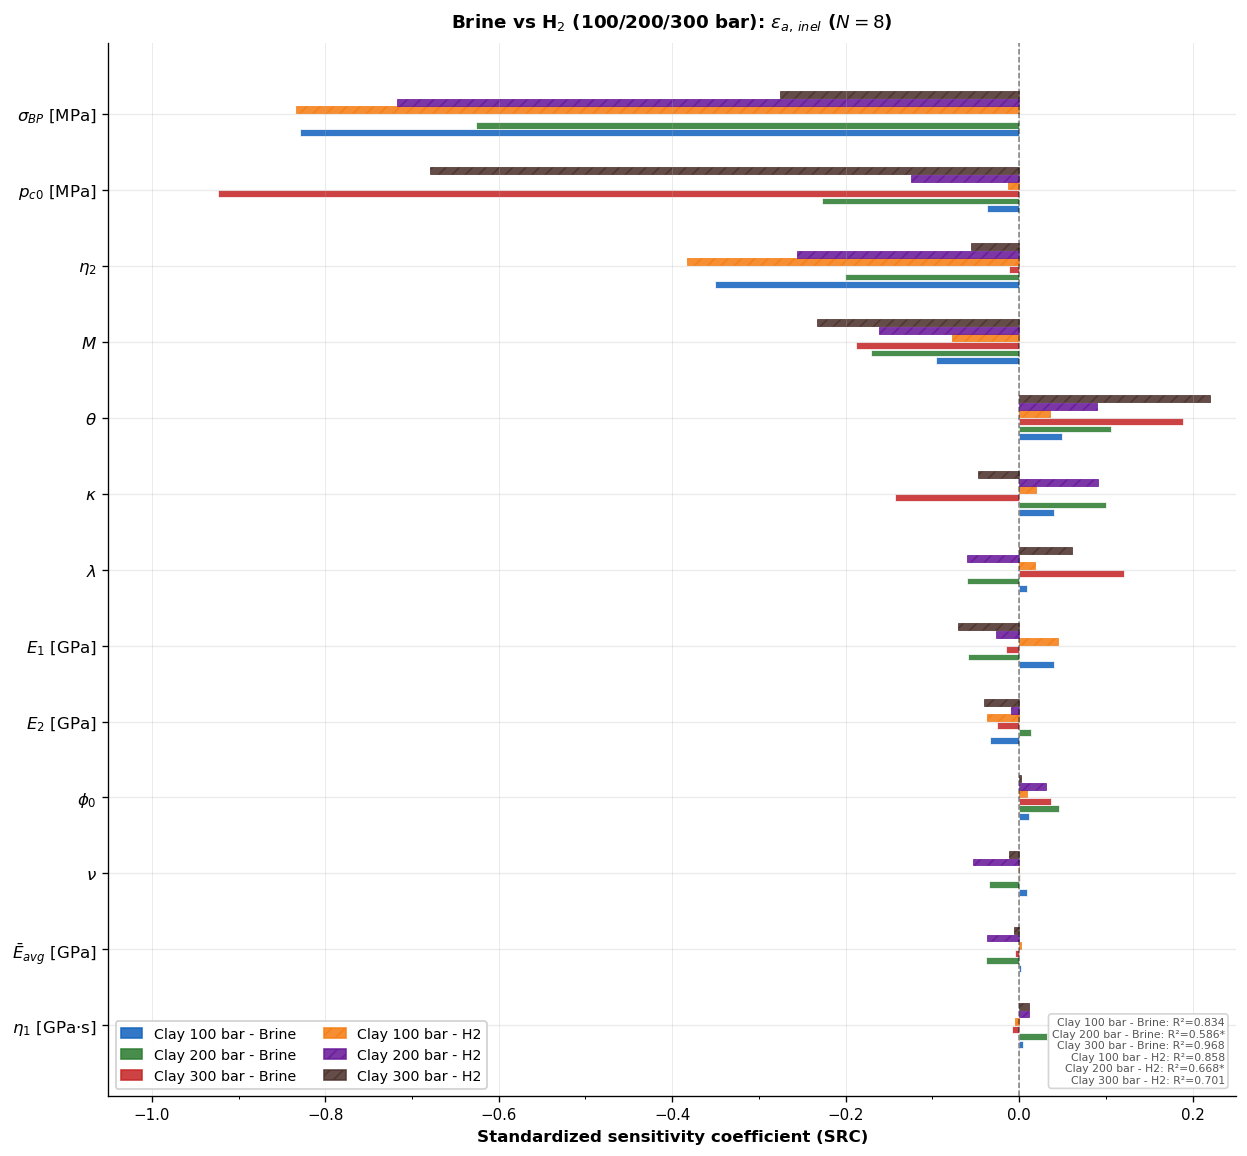

  Saved -> Outputs_Sensitivity_Analysis_Clay_Rich/Cell09_FigA_Sensitivity_eps_inel.pdf
  Saved -> Outputs_Sensitivity_Analysis_Clay_Rich/Cell09_FigA_Sensitivity_eps_inel.png
Fig A complete.


In [27]:
# =============================================================================
# CELL 09 — FIGURE A: SENSITIVITY — CUMULATIVE INELASTIC STRAIN (N=8)
# =============================================================================

CELL_NAME = "Cell09"    # cell prefix used in saved filenames

print("Generating Fig A — cumulative inelastic strain sensitivity...")

sa_draw('Y1', cell_name=CELL_NAME)    # draw tornado for metric Y1 (eps_inel at N=8)

print("Fig A complete.")


## Cell 10 — Figure B: Sensitivity — Ratcheting Rate

### What this cell produces
**Fig B** — Tornado plot for the **ratcheting rate**: the slope of the linear trend fitted through the cumulative inelastic strain evolution.

### Output metric definition
$$\dot{\varepsilon}_{ratch} = \text{slope of OLS fit through } \varepsilon_{inel}(1), \varepsilon_{inel}(2), \ldots, \varepsilon_{inel}(8)$$

### Physical interpretation
- A **high ratcheting rate** means the material accumulates more permanent strain each cycle → accelerating damage.
- A **low ratcheting rate** means hardening is keeping up with loading → stabilising behaviour.
- Ratcheting rate is more sensitive to **time-dependent parameters** (η₂, η₁) than cumulative strain, because creep mechanisms contribute progressively.

### Saved files
`Cell10_FigB_Sensitivity_ratcheting.pdf / .png`


Generating Fig B — ratcheting rate sensitivity...


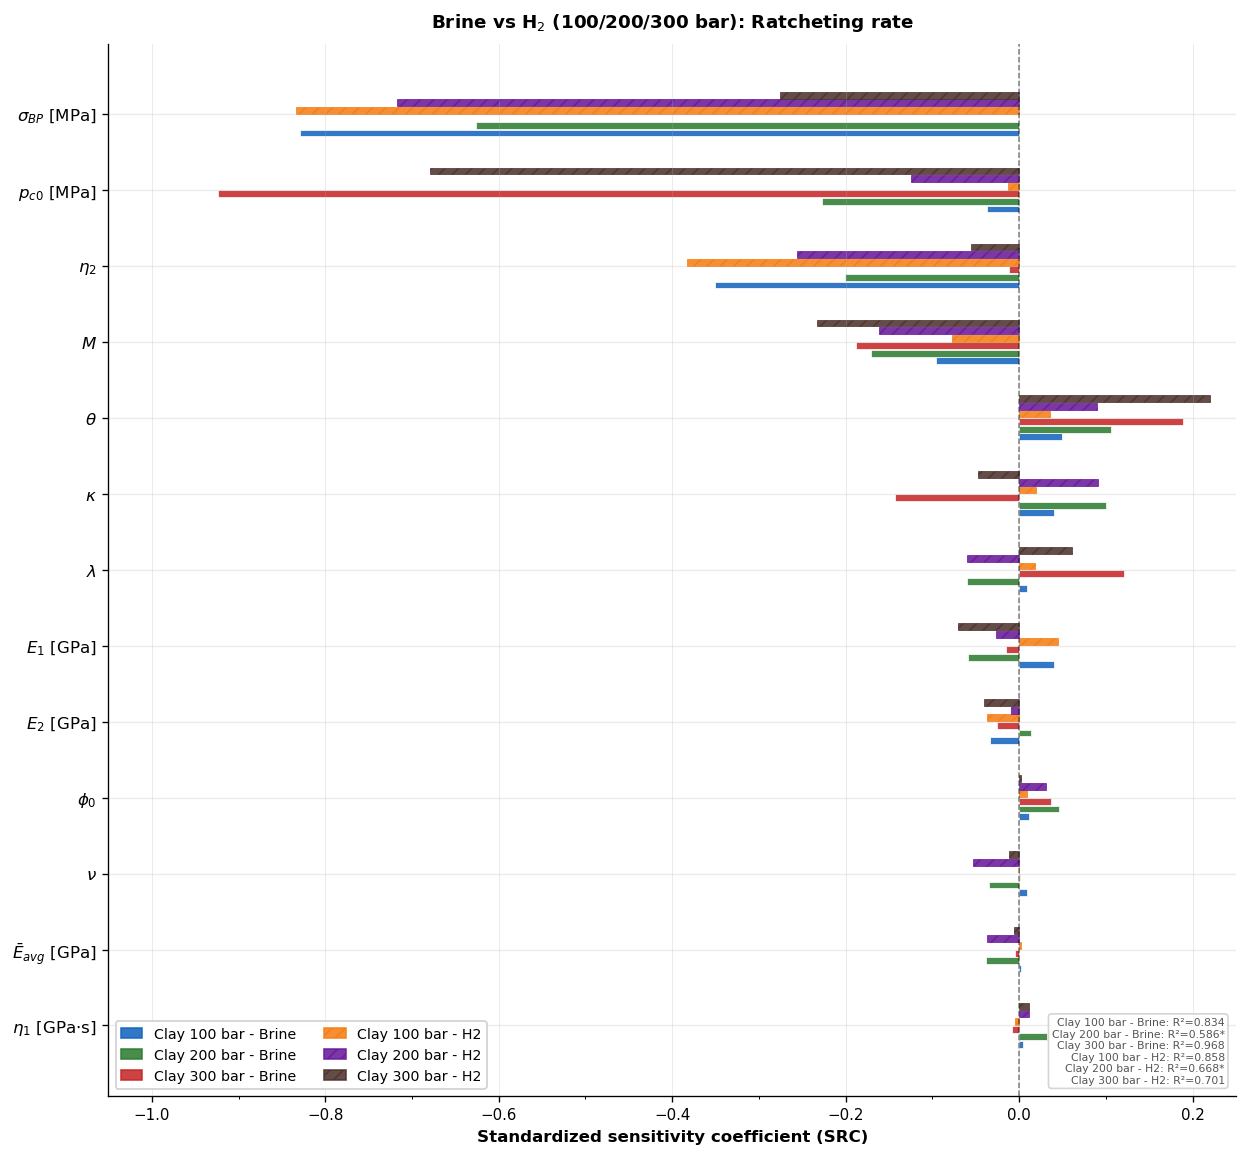

  Saved -> Outputs_Sensitivity_Analysis_Clay_Rich/Cell10_FigB_Sensitivity_ratcheting.pdf
  Saved -> Outputs_Sensitivity_Analysis_Clay_Rich/Cell10_FigB_Sensitivity_ratcheting.png
Fig B complete.


In [28]:
# =============================================================================
# CELL 10 — FIGURE B: SENSITIVITY — RATCHETING RATE
# =============================================================================

CELL_NAME = "Cell10"    # cell prefix used in saved filenames

print("Generating Fig B — ratcheting rate sensitivity...")

sa_draw('Y2', cell_name=CELL_NAME)    # draw tornado for metric Y2 (ratcheting rate)

print("Fig B complete.")


## Cell 11 — Figure C: Sensitivity — Mean Loop Area

### What this cell produces
**Fig C** — Tornado plot for the **mean loop area**: the average per-cycle strain increment, a proxy for energy dissipated per cycle.

### Output metric definition
$$A_{loop} = \frac{1}{N} \sum_{j=1}^{N} A_j, \quad A_j = q_{peak} \cdot \left(\varepsilon_{el} + 0.5\,\varepsilon_{pl} + 0.3\,\varepsilon_{ve}\right)$$

### Physical interpretation
- The **loop area** represents the **hysteretic energy** dissipated in each stress–strain cycle.
- Larger loop area → more energy converted to heat/damage per cycle.
- **Elastic moduli** (E₁, E₂, Eavg) tend to dominate loop area sensitivity because they control the elastic strain width of the loop.
- **λ and κ** control the plastic width.

### Saved files
`Cell11_FigC_Sensitivity_loop_area.pdf / .png`


Generating Fig C — mean loop area sensitivity...


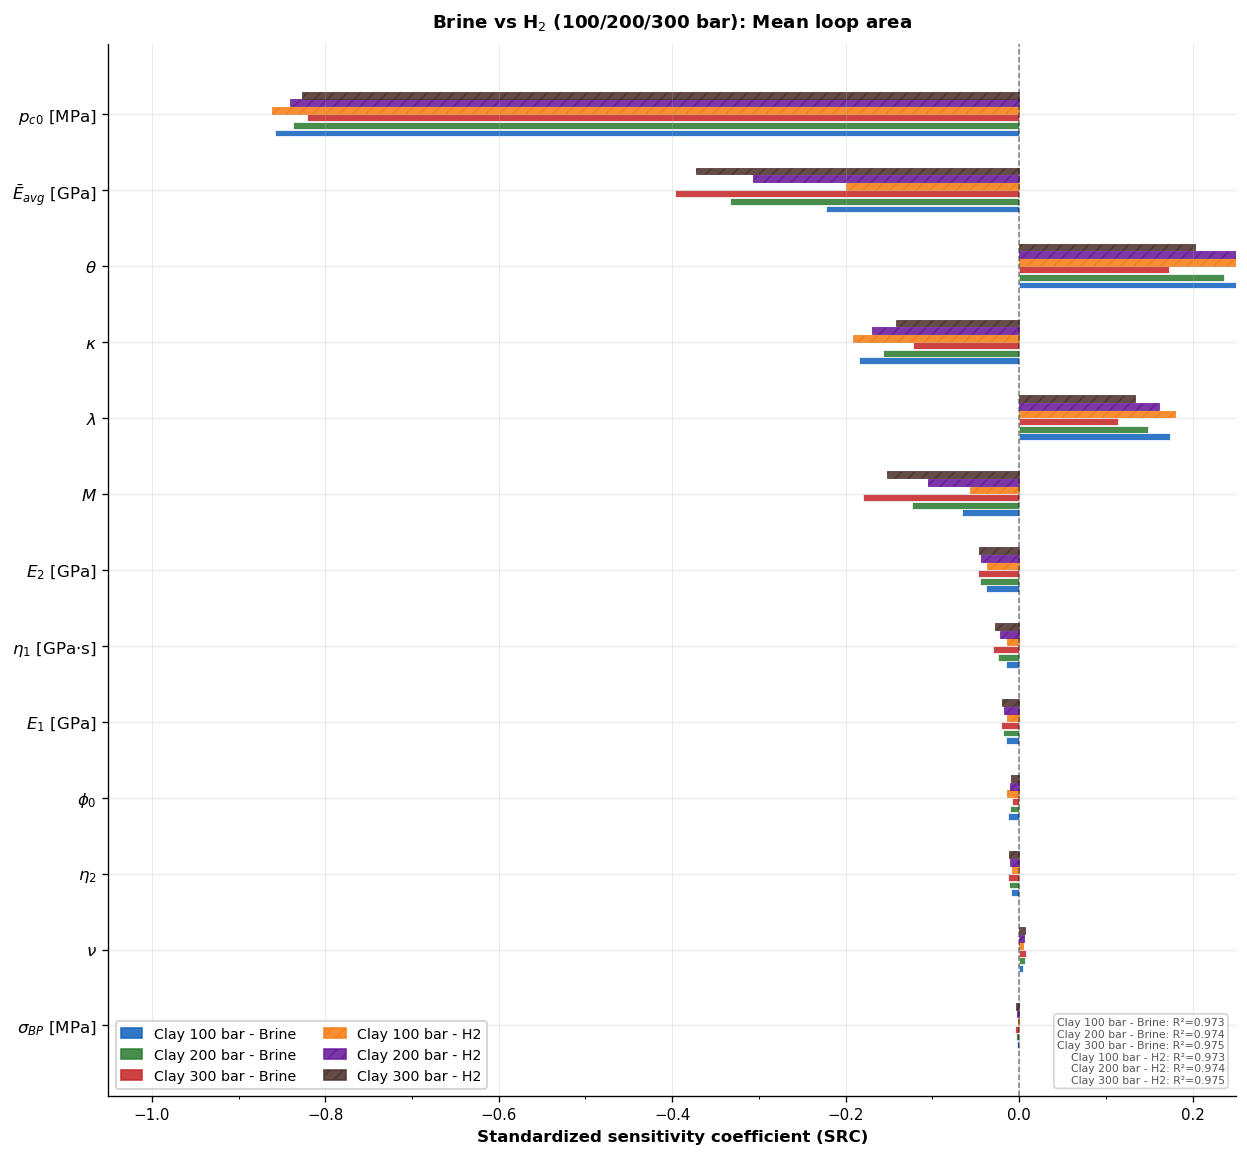

  Saved -> Outputs_Sensitivity_Analysis_Clay_Rich/Cell11_FigC_Sensitivity_loop_area.pdf
  Saved -> Outputs_Sensitivity_Analysis_Clay_Rich/Cell11_FigC_Sensitivity_loop_area.png
Fig C complete.


In [29]:
# =============================================================================
# CELL 11 — FIGURE C: SENSITIVITY — MEAN LOOP AREA
# =============================================================================

CELL_NAME = "Cell11"    # cell prefix used in saved filenames

print("Generating Fig C — mean loop area sensitivity...")

sa_draw('Y3', cell_name=CELL_NAME)    # draw tornado for metric Y3 (mean loop area)

print("Fig C complete.")


## Cell 12 — Figure D: Sensitivity — Total Axial Strain ε_total (N=8)

### What this cell produces
**Fig D** — Tornado plot for the **total axial strain** after 8 cycles (inelastic + elastic + viscoelastic).

### Output metric definition
$$\varepsilon_{a,\,total}(N=8) = \varepsilon_{inel}(8) + \varepsilon_{el} + \varepsilon_{ve}$$

### Comparison with Fig A
- Fig A (ε_inel only) captures only the **irreversible** strain component.
- Fig D (ε_total) adds the **recoverable** elastic and VE contributions.
- If elastic moduli appear more important in Fig D than Fig A, it confirms that **recoverable strain dominates** the total deformation budget for those cases.

### Saved files
`Cell12_FigD_Sensitivity_eps_total.pdf / .png`


Generating Fig D — total axial strain sensitivity...


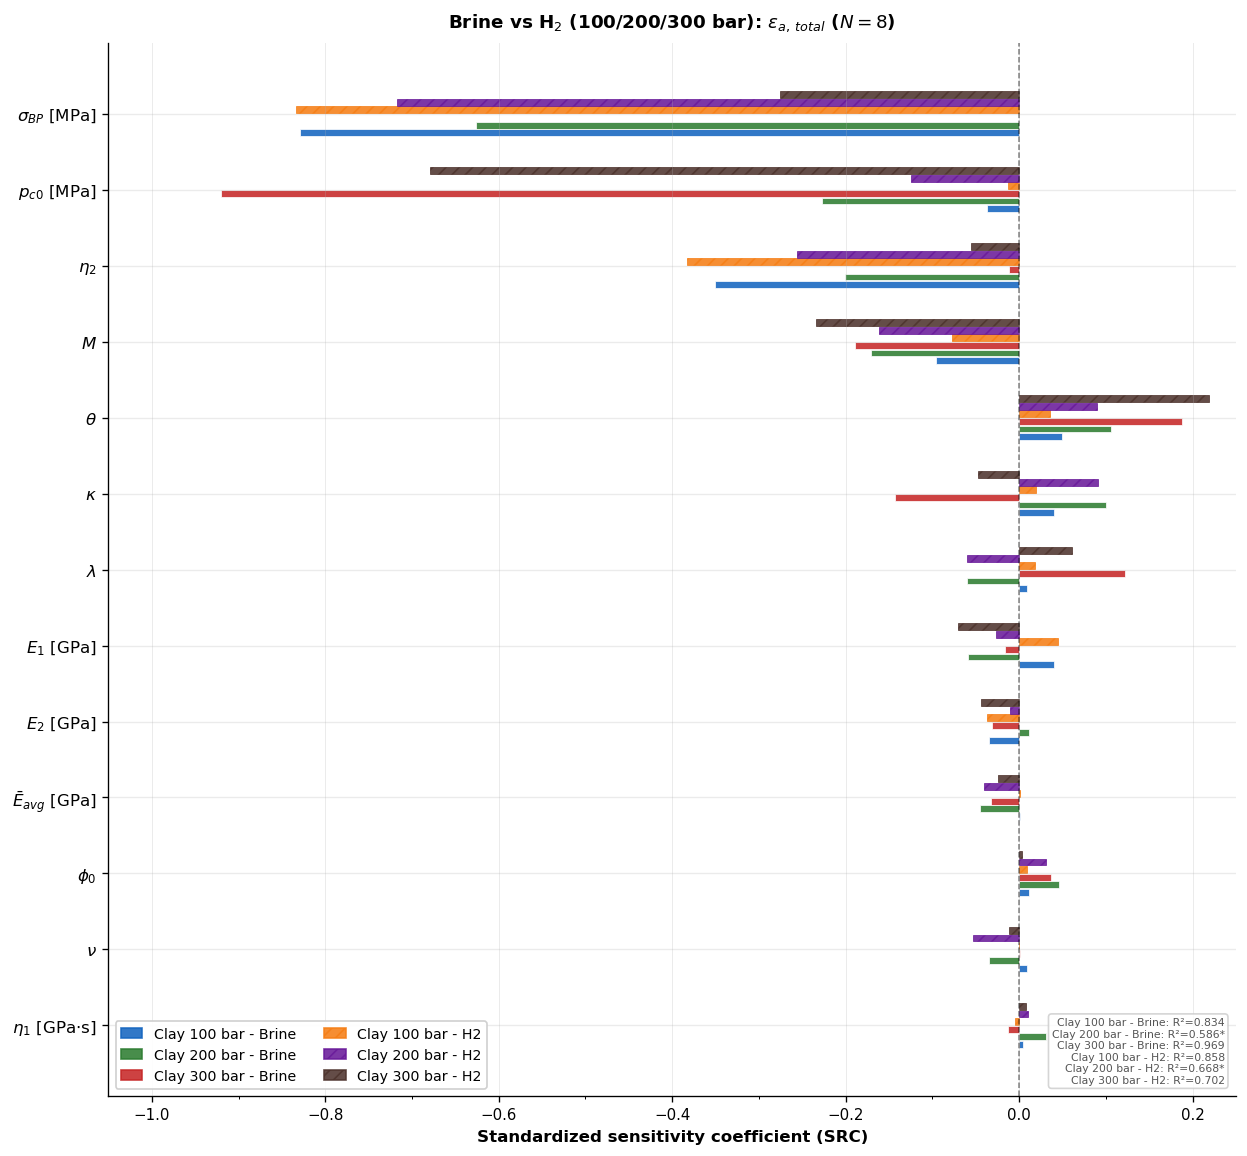

  Saved -> Outputs_Sensitivity_Analysis_Clay_Rich/Cell12_FigD_Sensitivity_eps_total.pdf
  Saved -> Outputs_Sensitivity_Analysis_Clay_Rich/Cell12_FigD_Sensitivity_eps_total.png
Fig D complete.


In [30]:
# =============================================================================
# CELL 12 — FIGURE D: SENSITIVITY — TOTAL AXIAL STRAIN (N=8)
# =============================================================================

CELL_NAME = "Cell12"    # cell prefix used in saved filenames

print("Generating Fig D — total axial strain sensitivity...")

sa_draw('Y4', cell_name=CELL_NAME)    # draw tornado for metric Y4 (eps_total at N=8)

print("Fig D complete.")


## Cell 13 — R² Summary Table & Figure Index

### Purpose
Print a complete table of R² goodness-of-fit values for every case and metric, plus the full index of saved files.

### What you will see
- R² table with a `*` flag on any value below 0.70.
- List of all 8 files (4 PDF + 4 PNG) saved to `Outputs_Sensitivity_Analysis_Clay_Rich/`.
- No figures produced here.

### Interpreting low R²
If R² < 0.70 for a case/metric combination:
1. **Increase `SA_N_SAMPLES`** from 120 to 300–500 to reduce sampling noise.
2. Consider **Sobol indices** (variance-based) instead of SRC for strongly nonlinear models.
3. Check whether the parameter range for that case is too wide, creating strong nonlinearity.


In [31]:
# =============================================================================
# CELL 13 — R² SUMMARY TABLE & FIGURE INDEX
# =============================================================================

# ── Figure index ──────────────────────────────────────────────────────────────
print()
print("=" * 65)
print(f"  Figures saved to: {OUTPUT_DIR}")
print("=" * 65)

fig_index = [
    f"Cell09_FigA_Sensitivity_eps_inel    — eps_inel at N=8",
    f"Cell10_FigB_Sensitivity_ratcheting  — ratcheting rate",
    f"Cell11_FigC_Sensitivity_loop_area   — mean loop area",
    f"Cell12_FigD_Sensitivity_eps_total   — eps_total at N=8",
]
for f in fig_index:
    # Print PDF and PNG filenames for each figure
    print(f"  {f}.pdf")
    print(f"  {f}.png")

# ── R² goodness-of-fit summary table ─────────────────────────────────────────
print()
print("=" * 65)
print("  R² summary  (* = R² < 0.70, nonlinear — increase SA_N_SAMPLES)")
print("=" * 65)
print(f"  {'Case':<26} {'Y1 eps_inel':>12} {'Y2 ratch.':>10} {'Y3 loop':>9} {'Y4 eps_tot':>11}")
print("  " + "─" * 70)

for fluid, p_label, *_ in SA_CASES:
    lbl = SA_RES[(fluid, p_label)]['label']       # case display label
    r1  = SA_RES[(fluid, p_label)]['Y1'][1]       # R² for cumulative inelastic strain
    r2  = SA_RES[(fluid, p_label)]['Y2'][1]       # R² for ratcheting rate
    r3  = SA_RES[(fluid, p_label)]['Y3'][1]       # R² for mean loop area
    r4  = SA_RES[(fluid, p_label)]['Y4'][1]       # R² for total strain

    # Flag cases where any metric has R² below the reliability threshold
    flg = "  <-- *" if min(r1, r2, r3, r4) < 0.7 else ""

    print(f"  {lbl:<26} {r1:>12.3f} {r2:>10.3f} {r3:>9.3f} {r4:>11.3f}{flg}")

print("=" * 65)
print()
print("All done. OK")



  Figures saved to: Outputs_Sensitivity_Analysis_Clay_Rich
  Cell09_FigA_Sensitivity_eps_inel    — eps_inel at N=8.pdf
  Cell09_FigA_Sensitivity_eps_inel    — eps_inel at N=8.png
  Cell10_FigB_Sensitivity_ratcheting  — ratcheting rate.pdf
  Cell10_FigB_Sensitivity_ratcheting  — ratcheting rate.png
  Cell11_FigC_Sensitivity_loop_area   — mean loop area.pdf
  Cell11_FigC_Sensitivity_loop_area   — mean loop area.png
  Cell12_FigD_Sensitivity_eps_total   — eps_total at N=8.pdf
  Cell12_FigD_Sensitivity_eps_total   — eps_total at N=8.png

  R² summary  (* = R² < 0.70, nonlinear — increase SA_N_SAMPLES)
  Case                        Y1 eps_inel  Y2 ratch.   Y3 loop  Y4 eps_tot
  ──────────────────────────────────────────────────────────────────────
  Clay 100 bar - Brine              0.834      0.834     0.973       0.834
  Clay 200 bar - Brine              0.586      0.586     0.974       0.586  <-- *
  Clay 300 bar - Brine              0.968      0.968     0.975       0.969
  Clay 100 bar